create humidex30, pr50, prsn50, drydays simulated p10/90 values across the 30 year temporal averages of their intervals
[1991, 2020], [2021,2050], [2041,2070]

In [2]:
import xarray as xr
from datetime import datetime
import cftime
import sys
import os
sys.path.append(r"C:\Users\CAMG038492\Code\Climatology\rasterization")
import rotated_coordinate #type:ignore
from scipy.stats import norm


In [34]:
intervalsx = [[1991-15, 2020-15],[2006, 2006+29], [2021,2050], [2041,2070]]
intervals = [[cftime.DatetimeNoLeap(i[0],1,1), cftime.DatetimeNoLeap(i[1],1,1)] for i in intervalsx]
vars = ['humidex30','prsn50','pr50','drydays']
scens = ['historical','rcp45','rcp85']

In [35]:
def run(var,inte,scen,perc:float,output='print',ver = 'regrid first'):
    # folder and dataset set up
    folder = r"C:\Data\humidex30".replace("humidex30",var)
    hist = r"C:\Data\humidex30\historical\originals\humidex30_NAM-22_CCCma-CanESM2_historical_r1i1p1_CCCma-CanRCM4_r2_day_19500101-20051231.nc".replace("humidex30", var)
    r45 = r"C:\Data\humidex30\rcp45\originals\humidex30_NAM-22_CCCma-CanESM2_rcp45_r1i1p1_CCCma-CanRCM4_r2_day_20060101-21001231.nc".replace("humidex30", var)
    r85 = r"C:\Data\humidex30\rcp85\originals\humidex30_NAM-22_CCCma-CanESM2_rcp85_r1i1p1_CCCma-CanRCM4_r2_day_20060101-21001231.nc".replace("humidex30", var)
    sets = [hist, r45, r85]
    dssets = [xr.open_dataset(t) for t in sets]
    sperc = str(int(perc * 100))

    print(f"running {var} {scen} {inte}")
    ds = dssets[scen]
    attrs = ds.attrs
    ds = ds.sel(time = slice(inte[0],inte[1]))
    if not ds[var].sum().values == 0:

        if ver == "regrid last": # calculates std+mean, calculates percentile, then regrids it
            std = ds.std(dim = 'time').fillna(0.)
            mean = ds.mean(dim = 'time').fillna(0.)
            pxx = xr.apply_ufunc(norm.ppf, xr.DataArray(perc), mean, std, vectorize=True, output_core_dims=[[]], output_dtypes=[float], keep_attrs=True)
            
            pxx = rotated_coordinate.rotated_pole_2_regular(pxx, input_format = 'ds', setting = 'canrcm4')

        if ver == "regrid first": # regrids original ds, calculates std+mean, then calculates percentile
            ds = rotated_coordinate.rotated_pole_2_regular(ds, input_format = 'ds', setting = 'canrcm4')
            std = ds.std(dim = 'time').fillna(0.)
            mean = ds.mean(dim = 'time').fillna(0.)
            pxx = xr.apply_ufunc(norm.ppf, xr.DataArray(perc), mean, std, vectorize=True, output_core_dims=[[]], output_dtypes=[float], keep_attrs=True)

        if ver == 'regrid second': # calculates std+mean, regrids them, then calculats percentile
            std = ds.std(dim = 'time').fillna(0.)
            mean = ds.mean(dim = 'time').fillna(0.)
            std = rotated_coordinate.rotated_pole_2_regular(std, input_format = 'ds', setting = 'canrcm4')
            mean = rotated_coordinate.rotated_pole_2_regular(mean, input_format = 'ds', setting = 'canrcm4')
            pxx = xr.apply_ufunc(norm.ppf, xr.DataArray(perc), mean, std, vectorize=True, output_core_dims=[[]], output_dtypes=[float], keep_attrs=True)

        name = f"{var}_{scens[scen]}_p{sperc}sim_{inte[0].year}-{inte[1].year}_annsum_30yp{sperc}sim.nc"
        pxx.attrs['wsp_annual_statistic'] = f'p{sperc}sim'
        pxx.attrs = attrs
        if output == 'print':
            return pxx
        if output == 'export':
            pxx.to_netcdf(os.path.join(folder,name))
            print(f"printed to {folder} {name}")
        

In [46]:
vartest = 'humidex30'
intetest = intervals[0]
scentest = scens[0]
percentile = 0.10
test1 = run(var=vartest, inte=intetest, scen=0, perc = 0.50, output = 'print', ver = 'regrid first')
test2 = run(var=vartest, inte=intetest, scen=0, perc = 0.50, output = 'print', ver = 'regrid second')
test3 = run(var=vartest, inte=intetest, scen=0, perc = 0.50, output = 'print', ver = 'regrid last')

running humidex30 0 [cftime.DatetimeNoLeap(1976, 1, 1, 0, 0, 0, 0, has_year_zero=True), cftime.DatetimeNoLeap(2005, 1, 1, 0, 0, 0, 0, has_year_zero=True)]


c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\xesmf\frontend.py:95: UserWarning: Variables {'rlat_bounds', 'rlon_bounds'} not found in object but are referred to in the CF attributes.
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\xesmf\frontend.py:96: UserWarning: Variables {'rlat_bounds', 'rlon_bounds'} not found in object but are referred to in the CF attributes.
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\xesmf\smm.py:197: RuntimeWarning: invalid value encountered in cast
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2323: RuntimeWarning: invalid value encountered in multiply
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\scipy\stats

running humidex30 0 [cftime.DatetimeNoLeap(1976, 1, 1, 0, 0, 0, 0, has_year_zero=True), cftime.DatetimeNoLeap(2005, 1, 1, 0, 0, 0, 0, has_year_zero=True)]


c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\xesmf\frontend.py:95: UserWarning: Variables {'rlat_bounds', 'rlon_bounds'} not found in object but are referred to in the CF attributes.
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\xesmf\frontend.py:96: UserWarning: Variables {'rlat_bounds', 'rlon_bounds'} not found in object but are referred to in the CF attributes.
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\xesmf\frontend.py:95: UserWarning: Variables {'rlat_bounds', 'rlon_bounds'} not found in object but are referred to in the CF attributes.
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\xesmf\frontend.py:96: UserWarning: Variables {'rlat_bounds', 'rlon_bounds'} not found in object but are referred t

running humidex30 0 [cftime.DatetimeNoLeap(1976, 1, 1, 0, 0, 0, 0, has_year_zero=True), cftime.DatetimeNoLeap(2005, 1, 1, 0, 0, 0, 0, has_year_zero=True)]


c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2323: RuntimeWarning: invalid value encountered in multiply
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2324: RuntimeWarning: invalid value encountered in multiply
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\xesmf\frontend.py:95: UserWarning: Variables {'rlat_bounds', 'rlon_bounds'} not found in object but are referred to in the CF attributes.
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\xesmf\frontend.py:96: UserWarning: Variables {'rlat_bounds', 'rlon_bounds'} not found in object but are referred to in the CF attributes.
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.


<xarray.DataArray 'pr50' ()> Size: 8B
array(0.03333333)
Coordinates:
    rotated_pole        |S1 1B b''
    latitude_longitude  float64 8B nan <xarray.DataArray 'pr50' ()> Size: 8B
array(3.55816947e-10)
Coordinates:
    rotated_pole        |S1 1B b''
    latitude_longitude  float64 8B nan <xarray.DataArray 'pr50' ()> Size: 8B
array(0.03333333)
Coordinates:
    rotated_pole        |S1 1B ...
    latitude_longitude  float64 8B nan


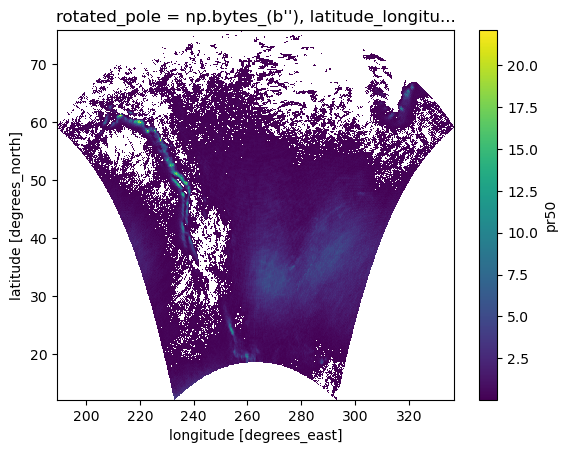

In [45]:
var = list(test1.data_vars)[0]
print(test1[var].min(), test2[var].min(), test3[var].min())
test1[var].plot()

In [ ]:
#iterate

for var in vars:
    for inte in intervals:
        for scen in range(len(scens)):
            print(run(var='humidex30', inte=intetest, scen=scentest, perc = 0.10, output = 'export'))


running humidex30 0 [cftime.DatetimeNoLeap(1976, 1, 1, 0, 0, 0, 0, has_year_zero=True), cftime.DatetimeNoLeap(2005, 1, 1, 0, 0, 0, 0, has_year_zero=True)]


c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2323: RuntimeWarning: invalid value encountered in multiply
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2324: RuntimeWarning: invalid value encountered in multiply
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\xesmf\frontend.py:95: UserWarning: Variables {'rlat_bounds', 'rlon_bounds'} not found in object but are referred to in the CF attributes.
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\xesmf\frontend.py:96: UserWarning: Variables {'rlat_bounds', 'rlon_bounds'} not found in object but are referred to in the CF attributes.
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
